In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Superstore_Sales.csv', encoding='latin1')
print(df.head())
print(df.info())

   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region       Product_ID         Cat

In [ ]:

print("Missing values before cleaning:\n", df.isnull().sum())

df = df.dropna(subset=['Sales', 'Order_Date'])

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

df = df.drop_duplicates()
df = df[df['Sales'] > 0]


total_revenue = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()
aov = total_revenue / total_orders

print(f"Total Revenue: {total_revenue}")
print(f"Average Order Value: {aov}")

Missing values before cleaning:
 Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64
Total Revenue: 2261536.7827000003
Average Order Value: 459.4751691791955


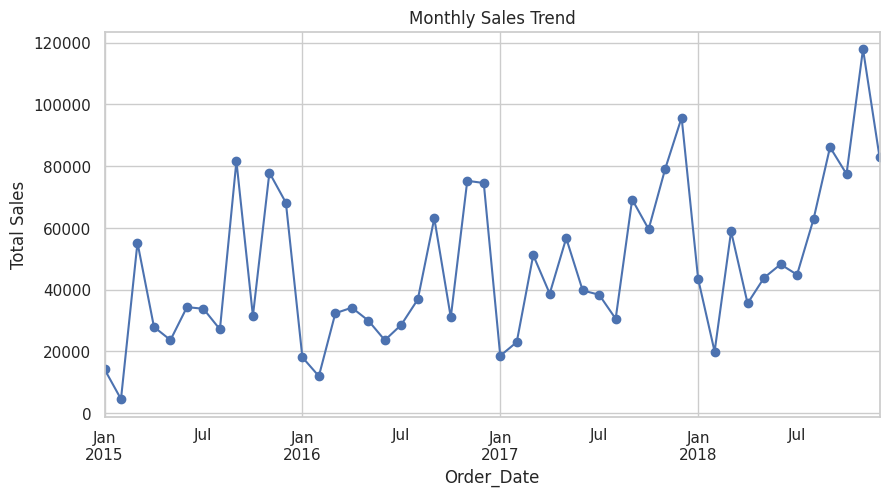

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum().plot(kind='line', figsize=(10, 5), marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()





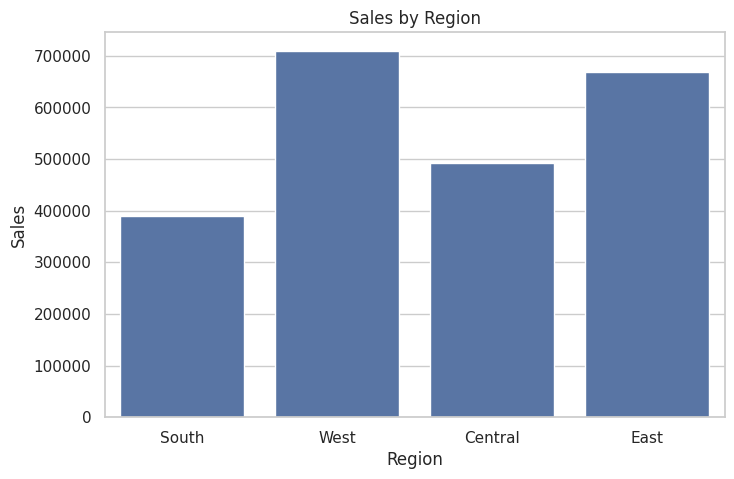

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Region', y='Sales', estimator=sum, errorbar=None)
plt.title('Sales by Region')
plt.show()


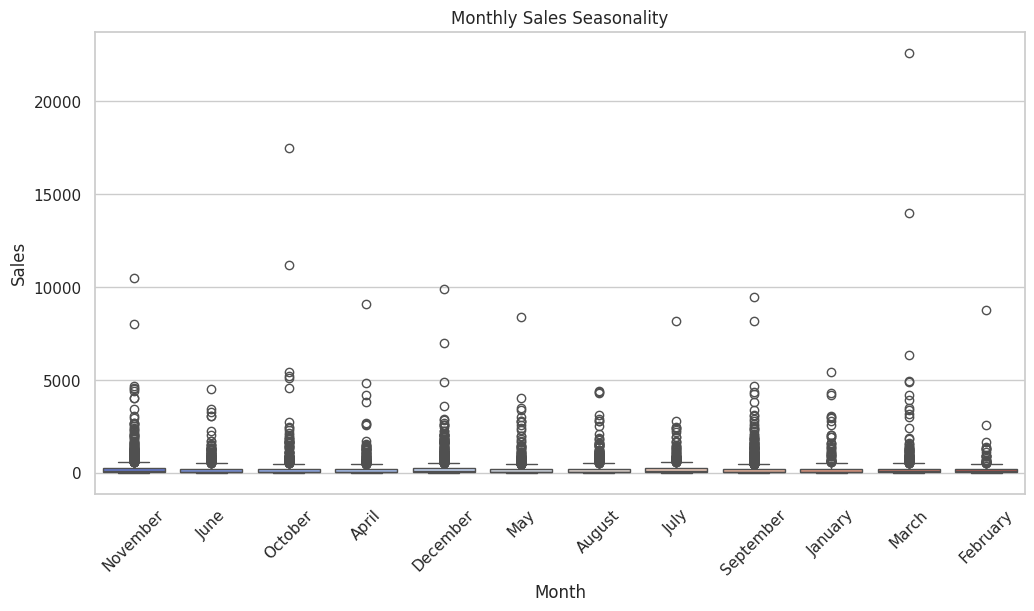

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
df['Month'] = df['Order_Date'].dt.month_name()

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Month', y='Sales', palette='coolwarm', hue='Month', legend=False)
plt.title('Monthly Sales Seasonality')
plt.xticks(rotation=45)
plt.show()

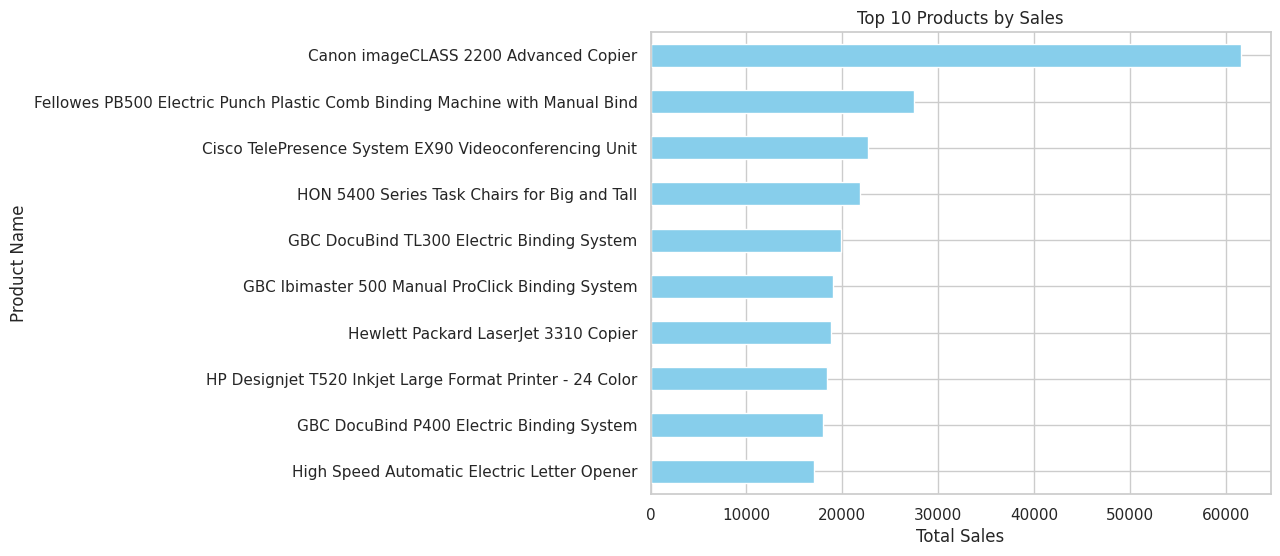

In [ ]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8, 6), color='skyblue')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis() # To display the highest sales at the top
plt.show()

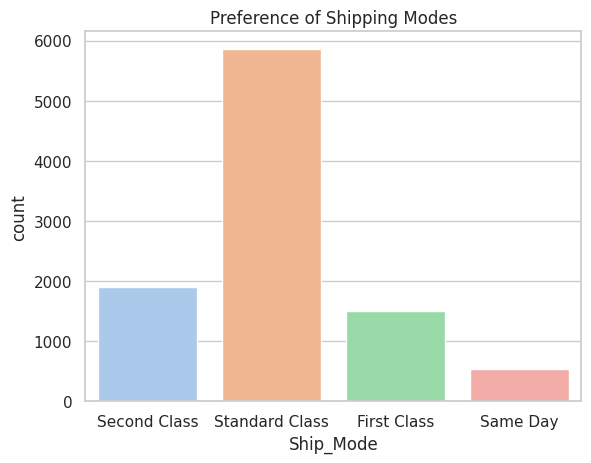

In [ ]:
sns.countplot(data=df, x='Ship_Mode', palette='pastel', hue='Ship_Mode', legend=False)
plt.title('Preference of Shipping Modes')
plt.show()

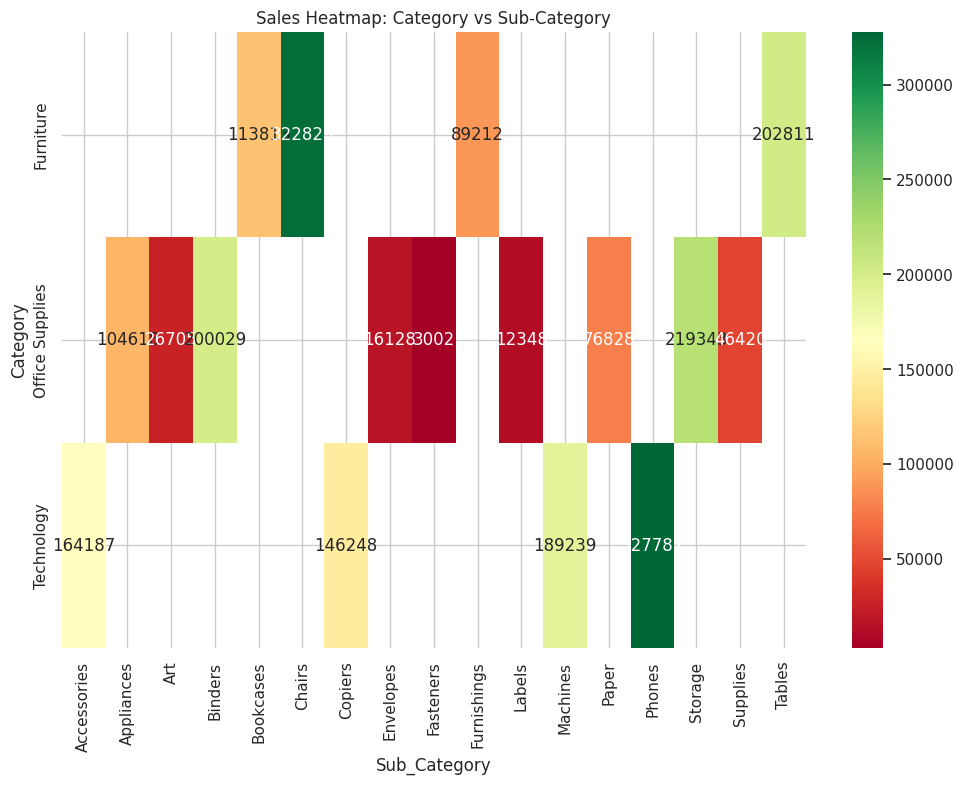

In [ ]:
pivot_df = df.pivot_table(index='Category', columns='Sub_Category', values='Sales', aggfunc='sum')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_df, annot=True, cmap='RdYlGn', fmt='.0f')
plt.title('Sales Heatmap: Category vs Sub-Category')
plt.show()